In [33]:
import pandas as pd

books = pd.read_parquet("../data/processed/works.parquet")
books

,title,title_source,subtitle,authors,authors_source,description,description_source,language,isbn13s,tags,...,sources,n_records,gr_popularity,gr_avg_rating,g7k_popularity,g7k_avg_rating,bx_popularity,bx_avg_rating,has_description,has_tags
work_id,,,,,,,,,,,,,,,,,,,,,
OL1000001W,Ghost Of A Chance,bookcrossing,NaN,[Bill Crider],bookcrossing,NaN,NaN,en,[9780373263967],"[Detective And Mystery Stories, Fiction, Gener...",...,[bookcrossing],1,0,NaN,0,NaN,4,NaN,False,True
OL1000005W,Murder most fowl,bookcrossing,NaN,[Bill Crider],bookcrossing,NaN,NaN,en,[9780312113872],"[Detective And Mystery Stories, Texas, Fiction...",...,[bookcrossing],1,0,NaN,0,NaN,1,NaN,False,True
OL100000W,Bloody Kin,bookcrossing,NaN,[Margaret Maron],bookcrossing,NaN,NaN,en,[9780385232319],"[Detective And Mystery Stories, Fiction, Gener...",...,[bookcrossing],1,0,NaN,0,NaN,4,NaN,False,True
OL1000012W,Outrage at Blanco,bookcrossing,NaN,[Bill Crider],bookcrossing,NaN,NaN,en,[9780440234548],"[Fiction, Rape, General, Revenge]",...,[bookcrossing],1,0,NaN,0,NaN,1,NaN,False,True
OL1000014W,A romantic way to die,bookcrossing,NaN,[Bill Crider],bookcrossing,NaN,NaN,en,"[9780312209070, 9780373264407]","[Detective And Mystery Stories, Romance, Texas...",...,[bookcrossing],2,0,NaN,0,NaN,4,9.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
unmapped_9997410440,Nine Hours to Rama,bookcrossing,NaN,[],NaN,NaN,NaN,NaN,[9789997410443],[],...,[bookcrossing],1,0,NaN,0,NaN,1,10.0,False,False
unmapped_9997550773,The Story of Ireland,bookcrossing,NaN,[],NaN,NaN,NaN,NaN,[9789997550774],[],...,[bookcrossing],1,0,NaN,0,NaN,1,NaN,False,False
unmapped_9997555627,My Sweet Orange Tree,bookcrossing,NaN,[],NaN,NaN,NaN,NaN,[9789997555625],[],...,[bookcrossing],1,0,NaN,0,NaN,1,NaN,False,False


#### Remove books without description
- cannot be used for "Similar to LOTR" queries
- filters out also most books that are not in english and have None in language

In [34]:
books = books[books["description"].notna()]
books

,title,title_source,subtitle,authors,authors_source,description,description_source,language,isbn13s,tags,...,sources,n_records,gr_popularity,gr_avg_rating,g7k_popularity,g7k_avg_rating,bx_popularity,bx_avg_rating,has_description,has_tags
work_id,,,,,,,,,,,,,,,,,,,,,
OL100003W,Home fires,bookcrossing,NaN,[Margaret Maron],bookcrossing,North Carolina judge Deborah Knott investigate...,bookcrossing,en,[9780446608107],"[Arson, Detective And Mystery Stories, Mystery...",...,[bookcrossing],1,0,NaN,0,NaN,8,5.333333,True,True
OL1000053W,No Marriage of Convenience (Avon Romantic Trea...,bookcrossing,NaN,[Elizabeth Boyle],bookcrossing,"Mason St. Clair, the new Earl of Ashlin, has i...",bookcrossing,en,[9780380815340],"[Fiction, History, General, Romance]",...,[bookcrossing],1,0,NaN,0,NaN,8,10.000000,True,True
OL1000055W,Once Tempted,bookcrossing,NaN,[Elizabeth Boyle],bookcrossing,"Innocence LostA notorious rake, the Marquis of...",bookcrossing,en,[9780380815357],"[Spain, Romance, Fiction, General, Man-Woman R...",...,[bookcrossing],1,0,NaN,0,NaN,7,9.500000,True,True
OL1000062W,It takes a hero,bookcrossing,NaN,[Elizabeth Boyle],bookcrossing,Rebecca will have to take a page from her own ...,bookcrossing,en,[9780060549305],"[Romance, Fiction, General, History, Social Li...",...,[bookcrossing],1,0,NaN,0,NaN,3,6.500000,True,True
OL1000064W,One Night of Passion,bookcrossing,NaN,[Elizabeth Boyle],bookcrossing,They Met At London's Notorious Cyprian's Ball....,bookcrossing,en,[9780786249909],"[Romance, Fiction, General, History, Social Li...",...,[bookcrossing],1,0,NaN,0,NaN,16,7.666667,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
unmapped_0911662251,Kybalion: A Study of the Hermetic Philosophy o...,goodreads,NaN,"[Three Initiates, William Walker Atkinson]",goodreads,Entre os fragmentos de conhecimentos ocultos p...,goodreads,en,[9780911662252],"[Philosophy, Occult, Spirituality, Nonfiction,...",...,"[bookcrossing, goodreads]",2,7266,4.21,0,NaN,3,NaN,True,True
unmapped_155709103X,George Washington's Rules of Civility and Dece...,google7k,NaN,[George Washington],google7k,Copied out by hand as a young man aspiring to ...,google7k,NaN,[9781557091031],[History],...,"[bookcrossing, google7k]",2,0,NaN,758,4.10,1,8.000000,True,True
unmapped_1568821441,The Keeper's Companion,google7k,"Blasphemous Knowledge, Forbidden Secrets, and ...",[Keith Herber],google7k,"[CALL OF CTHULHU ROLEPLAYING] ""The Keeper's Co...",google7k,NaN,[9781568821443],[Games],...,"[bookcrossing, google7k]",2,0,NaN,63,3.97,1,10.000000,True,True


In [35]:
books["title_and_subtitle"] = books["title"] + (": " + books["subtitle"]).fillna("")
books

,title,title_source,subtitle,authors,authors_source,description,description_source,language,isbn13s,tags,...,n_records,gr_popularity,gr_avg_rating,g7k_popularity,g7k_avg_rating,bx_popularity,bx_avg_rating,has_description,has_tags,title_and_subtitle
work_id,,,,,,,,,,,,,,,,,,,,,
OL100003W,Home fires,bookcrossing,NaN,[Margaret Maron],bookcrossing,North Carolina judge Deborah Knott investigate...,bookcrossing,en,[9780446608107],"[Arson, Detective And Mystery Stories, Mystery...",...,1,0,NaN,0,NaN,8,5.333333,True,True,Home fires
OL1000053W,No Marriage of Convenience (Avon Romantic Trea...,bookcrossing,NaN,[Elizabeth Boyle],bookcrossing,"Mason St. Clair, the new Earl of Ashlin, has i...",bookcrossing,en,[9780380815340],"[Fiction, History, General, Romance]",...,1,0,NaN,0,NaN,8,10.000000,True,True,No Marriage of Convenience (Avon Romantic Trea...
OL1000055W,Once Tempted,bookcrossing,NaN,[Elizabeth Boyle],bookcrossing,"Innocence LostA notorious rake, the Marquis of...",bookcrossing,en,[9780380815357],"[Spain, Romance, Fiction, General, Man-Woman R...",...,1,0,NaN,0,NaN,7,9.500000,True,True,Once Tempted
OL1000062W,It takes a hero,bookcrossing,NaN,[Elizabeth Boyle],bookcrossing,Rebecca will have to take a page from her own ...,bookcrossing,en,[9780060549305],"[Romance, Fiction, General, History, Social Li...",...,1,0,NaN,0,NaN,3,6.500000,True,True,It takes a hero
OL1000064W,One Night of Passion,bookcrossing,NaN,[Elizabeth Boyle],bookcrossing,They Met At London's Notorious Cyprian's Ball....,bookcrossing,en,[9780786249909],"[Romance, Fiction, General, History, Social Li...",...,1,0,NaN,0,NaN,16,7.666667,True,True,One Night of Passion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
unmapped_0911662251,Kybalion: A Study of the Hermetic Philosophy o...,goodreads,NaN,"[Three Initiates, William Walker Atkinson]",goodreads,Entre os fragmentos de conhecimentos ocultos p...,goodreads,en,[9780911662252],"[Philosophy, Occult, Spirituality, Nonfiction,...",...,2,7266,4.21,0,NaN,3,NaN,True,True,Kybalion: A Study of the Hermetic Philosophy o...
unmapped_155709103X,George Washington's Rules of Civility and Dece...,google7k,NaN,[George Washington],google7k,Copied out by hand as a young man aspiring to ...,google7k,NaN,[9781557091031],[History],...,2,0,NaN,758,4.10,1,8.000000,True,True,George Washington's Rules of Civility and Dece...
unmapped_1568821441,The Keeper's Companion,google7k,"Blasphemous Knowledge, Forbidden Secrets, and ...",[Keith Herber],google7k,"[CALL OF CTHULHU ROLEPLAYING] ""The Keeper's Co...",google7k,NaN,[9781568821443],[Games],...,2,0,NaN,63,3.97,1,10.000000,True,True,"The Keeper's Companion: Blasphemous Knowledge,..."


In [36]:
books = books[["title", "subtitle", "title_and_subtitle", "authors", "description", "language", "isbn13s", "tags", "year", "bx_popularity", "gr_popularity", "description_source"]]
books

,title,subtitle,title_and_subtitle,authors,description,language,isbn13s,tags,year,bx_popularity,gr_popularity,description_source
work_id,,,,,,,,,,,,
OL100003W,Home fires,NaN,Home fires,[Margaret Maron],North Carolina judge Deborah Knott investigate...,en,[9780446608107],"[Arson, Detective And Mystery Stories, Mystery...",2000,8,0,bookcrossing
OL1000053W,No Marriage of Convenience (Avon Romantic Trea...,NaN,No Marriage of Convenience (Avon Romantic Trea...,[Elizabeth Boyle],"Mason St. Clair, the new Earl of Ashlin, has i...",en,[9780380815340],"[Fiction, History, General, Romance]",2000,8,0,bookcrossing
OL1000055W,Once Tempted,NaN,Once Tempted,[Elizabeth Boyle],"Innocence LostA notorious rake, the Marquis of...",en,[9780380815357],"[Spain, Romance, Fiction, General, Man-Woman R...",2001,7,0,bookcrossing
OL1000062W,It takes a hero,NaN,It takes a hero,[Elizabeth Boyle],Rebecca will have to take a page from her own ...,en,[9780060549305],"[Romance, Fiction, General, History, Social Li...",2004,3,0,bookcrossing
OL1000064W,One Night of Passion,NaN,One Night of Passion,[Elizabeth Boyle],They Met At London's Notorious Cyprian's Ball....,en,[9780786249909],"[Romance, Fiction, General, History, Social Li...",2002,16,0,bookcrossing
...,...,...,...,...,...,...,...,...,...,...,...,...
unmapped_0911662251,Kybalion: A Study of the Hermetic Philosophy o...,NaN,Kybalion: A Study of the Hermetic Philosophy o...,"[Three Initiates, William Walker Atkinson]",Entre os fragmentos de conhecimentos ocultos p...,en,[9780911662252],"[Philosophy, Occult, Spirituality, Nonfiction,...",1908,3,7266,goodreads
unmapped_155709103X,George Washington's Rules of Civility and Dece...,NaN,George Washington's Rules of Civility and Dece...,[George Washington],Copied out by hand as a young man aspiring to ...,NaN,[9781557091031],[History],1989,1,0,google7k
unmapped_1568821441,The Keeper's Companion,"Blasphemous Knowledge, Forbidden Secrets, and ...","The Keeper's Companion: Blasphemous Knowledge,...",[Keith Herber],"[CALL OF CTHULHU ROLEPLAYING] ""The Keeper's Co...",NaN,[9781568821443],[Games],2000,1,0,google7k


### Description lengths
- long right tail

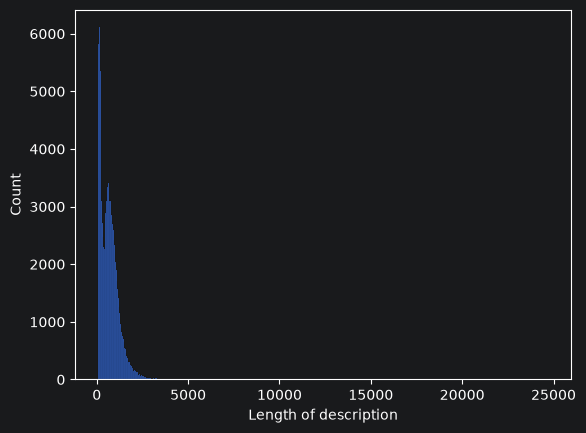

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = plt.axes()
sns.histplot(books["description"].str.len())

plt.xlabel("Length of description")
plt.ylabel("Count")

plt.show()


In [38]:
books["description"].str.len().describe()

count    103690.000000
mean        684.807166
std         539.754690
min          50.000000
25%         250.000000
50%         612.000000
75%         950.000000
max       24731.000000
Name: description, dtype: float64

### Further remove boilerplate and non-english descriptions

In [39]:
import re
import sys

sys.path.append("../src")
from catalog.normalize import normalize_title, author_key

In [40]:
def _normalize_text(text: pd.Series) -> pd.Series:
    return text.str.casefold().str.split().str.join(" ")


def shared_description_mask(
    books: pd.DataFrame,
    min_titles: int = 2,
    prefix_chars: int | None = None,
) -> pd.Series:
    """True for books whose description is also used by a book with a different title;
    can reveal boilerplate descriptions
    Same description + different titles is publisher text
    ("This scarce antiquarian book is a facsimile reprint...") and says nothing about the book.
    """
    for col in ("title", "description"):
        if col not in books.columns:
            raise KeyError(f"Missing column: {col}")

    description = _normalize_text(books["description"])
    if prefix_chars is not None:
        description = description.str[:prefix_chars]
    title = books["title"].map(normalize_title)

    n_titles = title.groupby(description).transform("nunique")
    return n_titles.fillna(0) >= min_titles

def classify_shared_descriptions(books: pd.DataFrame, max_duplicate_titles: int = 3) -> pd.Series:
    """Label each book 'unique', 'duplicate' or 'boilerplate' based on its description.
    """
    for col in ("title", "authors", "description"):
        if col not in books.columns:
            raise KeyError(f"Missing column: {col}")

    description = _normalize_text(books["description"])
    author = books["authors"].map(lambda a: author_key(a[0]) if len(a) else None)
    title = books["title"].map(normalize_title)

    n_books = description.groupby(description).transform("size")
    n_authors = author.groupby(description).transform("nunique")   # missing authors are not counted
    n_titles = title.groupby(description).transform("nunique")

    label = pd.Series("unique", index=books.index)
    label[n_books > 1] = "duplicate"
    label[(n_books > 1) & ((n_authors >= 2) | (n_titles > max_duplicate_titles))] = "boilerplate"
    return label

In [41]:
shared = shared_description_mask(books, min_titles=3)
print(f"{shared.sum():,} books share a description with a differently titled book")

(books.loc[shared, ["title", "description"]]
      .assign(description=lambda d: d["description"].str[:100])
      .sort_values("description")
      .head(30))

184 books share a description with a differently titled book


,title,description
work_id,,
OL100089W,The First Book of Lost Swords,"A blend of science fiction and fantasy, the Bo..."
OL100094W,The lost swords,"A blend of science fiction and fantasy, the Bo..."
OL100109W,Stonecutter's story,"A blend of science fiction and fantasy, the Bo..."
OL100113W,The Second Book of Swords,"A blend of science fiction and fantasy, the Bo..."
OL15407135W,Go hang a salami! I'm a lasagna hog!,"A collection of palindromes, sentences that re..."
OL15831511W,Jon Agee's palindromania,"A collection of palindromes, sentences that re..."
OL1933040W,Go Hang a Salami! I'm a Lasagna Hog! and Other...,"A collection of palindromes, sentences that re..."
OL19066597W,"Sailor Moon, Vol. 8",A graphic novel featuring the further adventur...
OL5855227W,"Sailor Moon, Vol. 10",A graphic novel featuring the further adventur...


In [44]:
books["desc_class"] = classify_shared_descriptions(books)
print(books["desc_class"].value_counts())

def show(label: str, n: int = 30) -> pd.DataFrame:
    return (books[books["desc_class"] == label]
            .assign(desc=lambda d: d["description"].str[:70])
            .sort_values("desc")[["title", "authors", "desc"]]
            .head(n))

show("boilerplate")

desc_class
unique         102994
boilerplate       388
duplicate         308
Name: count, dtype: int64


,title,authors,desc
work_id,,,
OL116588W,Heidi,[Susan Saunders],A Swiss orphan is heartbroken when she must le...
OL16048918W,Heidi,[Celia Bland],A Swiss orphan is heartbroken when she must le...
OL484718W,"Sarah Hughes, Golden Girl",[Nancy E. Krulik],A biography of the sixteen-year-old figure ska...
OL5963678W,Going for the gold,[R. S. Ashby],A biography of the sixteen-year-old figure ska...
OL15562594W,"The story of Laura Ingalls Wilder, pioneer girl",[Megan Stine],A biography of the writer whose pioneer life o...
OL2161977W,Laura Ingalls Wilder,[William Anderson],A biography of the writer whose pioneer life o...
OL100089W,The First Book of Lost Swords,[Fred Saberhagen],"A blend of science fiction and fantasy, the Bo..."
OL100094W,The lost swords,[Fred Saberhagen],"A blend of science fiction and fantasy, the Bo..."
OL100109W,Stonecutter's story,[Fred Saberhagen],"A blend of science fiction and fantasy, the Bo..."


#### Keep only first record of books with duplicated description

In [46]:
books = books[~books["description"].str.casefold().str.split().str.join(" ").duplicated()]
books

,title,subtitle,title_and_subtitle,authors,description,language,isbn13s,tags,year,bx_popularity,gr_popularity,description_source,desc_class
work_id,,,,,,,,,,,,,
OL100003W,Home fires,NaN,Home fires,[Margaret Maron],North Carolina judge Deborah Knott investigate...,en,[9780446608107],"[Arson, Detective And Mystery Stories, Mystery...",2000,8,0,bookcrossing,unique
OL1000053W,No Marriage of Convenience (Avon Romantic Trea...,NaN,No Marriage of Convenience (Avon Romantic Trea...,[Elizabeth Boyle],"Mason St. Clair, the new Earl of Ashlin, has i...",en,[9780380815340],"[Fiction, History, General, Romance]",2000,8,0,bookcrossing,unique
OL1000055W,Once Tempted,NaN,Once Tempted,[Elizabeth Boyle],"Innocence LostA notorious rake, the Marquis of...",en,[9780380815357],"[Spain, Romance, Fiction, General, Man-Woman R...",2001,7,0,bookcrossing,unique
OL1000062W,It takes a hero,NaN,It takes a hero,[Elizabeth Boyle],Rebecca will have to take a page from her own ...,en,[9780060549305],"[Romance, Fiction, General, History, Social Li...",2004,3,0,bookcrossing,unique
OL1000064W,One Night of Passion,NaN,One Night of Passion,[Elizabeth Boyle],They Met At London's Notorious Cyprian's Ball....,en,[9780786249909],"[Romance, Fiction, General, History, Social Li...",2002,16,0,bookcrossing,unique
...,...,...,...,...,...,...,...,...,...,...,...,...,...
unmapped_0911662251,Kybalion: A Study of the Hermetic Philosophy o...,NaN,Kybalion: A Study of the Hermetic Philosophy o...,"[Three Initiates, William Walker Atkinson]",Entre os fragmentos de conhecimentos ocultos p...,en,[9780911662252],"[Philosophy, Occult, Spirituality, Nonfiction,...",1908,3,7266,goodreads,unique
unmapped_155709103X,George Washington's Rules of Civility and Dece...,NaN,George Washington's Rules of Civility and Dece...,[George Washington],Copied out by hand as a young man aspiring to ...,NaN,[9781557091031],[History],1989,1,0,google7k,unique
unmapped_1568821441,The Keeper's Companion,"Blasphemous Knowledge, Forbidden Secrets, and ...","The Keeper's Companion: Blasphemous Knowledge,...",[Keith Herber],"[CALL OF CTHULHU ROLEPLAYING] ""The Keeper's Co...",NaN,[9781568821443],[Games],2000,1,0,google7k,unique


#### Drop books with non-english description that stayed in the dataset

In [47]:
# Very frequent in any English text, rare in other languages.
ENGLISH_FUNCTION_WORDS: frozenset[str] = frozenset({
    "the", "and", "of", "to", "in", "is", "was", "he", "she", "his", "her", "it", "with",
    "for", "that", "on", "as", "by", "this", "are", "from", "at", "or", "but", "not",
    "have", "has", "they", "their", "who", "which", "will", "when", "into", "be", "been",
})
_WORD = re.compile(r"[^\W\d_]+")  # letters of any alphabet, so Cyrillic/Greek words count too


def english_word_ratio(text: object) -> float:
    """Share of words that are English function words. NaN for missing text, 0.0 for no words."""
    if not isinstance(text, str):
        return float("nan")
    words = _WORD.findall(text.casefold())
    if not words:
        return 0.0
    return sum(word in ENGLISH_FUNCTION_WORDS for word in words) / len(words)


def is_english_text(descriptions: pd.Series, threshold: float) -> pd.Series:
    """True where the description looks English. Missing descriptions -> False."""
    return descriptions.map(english_word_ratio).fillna(0.0) >= threshold

In [48]:
books["en_ratio"] = books["description"].map(english_word_ratio)
books["en_ratio"].describe(percentiles=[0.005, 0.01, 0.02, 0.05, 0.5])

count    103278.000000
mean          0.316896
std           0.066812
min           0.000000
0.5%          0.000000
1%            0.024006
2%            0.142857
5%            0.209302
50%           0.322917
max           0.600000
Name: en_ratio, dtype: float64

In [51]:
# Read examples in each band: where does English stop?
bins = [0.0, 0.03, 0.04, 0.05, 0.06, 0.09, 0.12, 0.15, 0.20]
for low, high in zip(bins, bins[1:]):
    band = books[(books["en_ratio"] >= low) & (books["en_ratio"] < high)]
    print(f"\n[{low:.2f}, {high:.2f})  n={len(band):,}")
    for text in band["description"].sample(min(5, len(band)), random_state=0):
        print("   ", text[:110])


[0.00, 0.03)  n=1,066
    Yudith adalah seorang quiz hunter yang sering memenangkan berbagai hadiah, mulai dari merchandises, sampai non
    في هذا الكتاب تمنحك فلورنس ليتور أفكاراً قيمة لتقدير شخصيتك الفريدة من نوعها التي وهبها الله لك. وهي تدرج اختب
    Evercity er den siste delen av trilogien om Evv Lushon. Sammen med Lushons plater og Anubis utgjør denne roman
    Un adevărat revoluţionar al timpului său - a luat parte activ la mişcarea Risorgimento din Italia mijlocului d
    Qu'une vieille mule comme Amédée Fleurissoire rencontre des escrocs, et le voilà en route pour Rome, persuadé 

[0.03, 0.04)  n=55
    Na haar moeilijke tijd in donker Parijs, weet Angelique door te dringen tot het slot van Versailles en een bet
    **Morenga** ist ein postkolonialer Roman von Uwe Timm. Das Werk erschien 1978 in der AutorenEdition. Der Titel
    Wenn Bücher lebendig werden ... In einer stürmischen Nacht taucht ein unheimlicher Gast bei Meggie und ihrem V
    **The X Windows System:** - [Volu

< 0.05 seems like a good threshold for non-english descriptions

In [52]:
THRESHOLD = 0.05
english = is_english_text(books["description"], THRESHOLD)
print(f"Removing {(~english).sum():,} non-English descriptions")
books = books[english].drop(columns="en_ratio")

Removing 1,161 non-English descriptions


#### Save the final dataset

In [53]:
books.to_parquet("../data/books-final.parquet")